In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parents[1]
sys.path.append(str(PROJECT_ROOT))

In [7]:
from loaders._load_vn30_binary import preprocess, VN30, TARGETS
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import balanced_accuracy_score, confusion_matrix

In [3]:
_ = preprocess("ACB", verbose=True)

=== Preprocessing ACB ===
Feature shapes: train (1215, 120), validation (0, 120), test (298, 120)
Label distribution: train Counter({np.int64(0): 644, np.int64(1): 571}), validation Counter(), test Counter({np.int64(0): 163, np.int64(1): 135})


In [8]:
for symbol in VN30:
    data = preprocess(symbol, lag=30, lag_label=True)
    X_train, Y_train = data["train"]
    X_test, Y_test = data["test"]

    model = RandomForestClassifier(
        n_estimators=100,
        max_depth=8,
        random_state=42
    )

    model.fit(X_train, Y_train)

    train_preds = model.predict(X_train)
    test_preds = model.predict(X_test)

    print(f"Symbol: {symbol}")
    print(f"Train Balanced Accuracy: {balanced_accuracy_score(Y_train, train_preds)}")
    print(f"Test Balanced Accuracy: {balanced_accuracy_score(Y_test, test_preds)}")
    print(f"Test Confusion Matrix:\n{confusion_matrix(Y_test, test_preds)}\n")

Symbol: ACB
Train Balanced Accuracy: 0.906573952203283
Test Balanced Accuracy: 0.5
Test Confusion Matrix:
[[  0 163]
 [  0 135]]

Symbol: BCM
Train Balanced Accuracy: 0.8326539855072463
Test Balanced Accuracy: 0.5141507270308702
Test Confusion Matrix:
[[124  45]
 [ 91  38]]

Symbol: BID
Train Balanced Accuracy: 0.9336470157056775
Test Balanced Accuracy: 0.4917964404894327
Test Confusion Matrix:
[[108  66]
 [ 79  45]]

Symbol: BVH
Train Balanced Accuracy: 0.9081081081081082
Test Balanced Accuracy: 0.5064465626007275
Test Confusion Matrix:
[[118  53]
 [ 86  41]]

Symbol: CTG
Train Balanced Accuracy: 0.9532327586206897
Test Balanced Accuracy: 0.5415915645277578
Test Confusion Matrix:
[[113  33]
 [105  47]]

Symbol: FPT
Train Balanced Accuracy: 0.921206981363855
Test Balanced Accuracy: 0.5
Test Confusion Matrix:
[[146   0]
 [152   0]]

Symbol: GAS
Train Balanced Accuracy: 0.9319196067651909
Test Balanced Accuracy: 0.5008003766478343
Test Confusion Matrix:
[[133  47]
 [ 87  31]]

Symbol: GV

In [9]:
symbol = "ACB"

train_bacc = {
    "by_lag": [],
    "by_tree": [],
    "by_depth": []
}

test_bacc = {
    "by_lag": [],
    "by_tree": [],
    "by_depth": []
}

for lag in [3, 7, 14, 21, 30]:
    data = preprocess(symbol, lag=lag, lag_label=True)
    X_train, Y_train = data["train"]
    X_test, Y_test = data["test"]

    model = RandomForestClassifier(
        n_estimators=100,
        max_depth=8,
        random_state=42
    )

    model.fit(X_train, Y_train)

    train_preds = model.predict(X_train)
    test_preds = model.predict(X_test)

    train_bacc["by_lag"].append(balanced_accuracy_score(Y_train, train_preds))
    test_bacc["by_lag"].append(balanced_accuracy_score(Y_test, test_preds))

for n_estimators in range(10, 201, 10):
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=8,
        random_state=42
    )

    model.fit(X_train, Y_train)

    train_preds = model.predict(X_train)
    test_preds = model.predict(X_test)

    train_bacc["by_tree"].append(balanced_accuracy_score(Y_train, train_preds))
    test_bacc["by_tree"].append(balanced_accuracy_score(Y_test, test_preds))

for max_depth in range(1, 21):
    model = RandomForestClassifier(
        n_estimators=100,
        max_depth=max_depth,
        random_state=42
    )

    model.fit(X_train, Y_train)

    train_preds = model.predict(X_train)
    test_preds = model.predict(X_test)

    train_bacc["by_depth"].append(balanced_accuracy_score(Y_train, train_preds))
    test_bacc["by_depth"].append(balanced_accuracy_score(Y_test, test_preds))

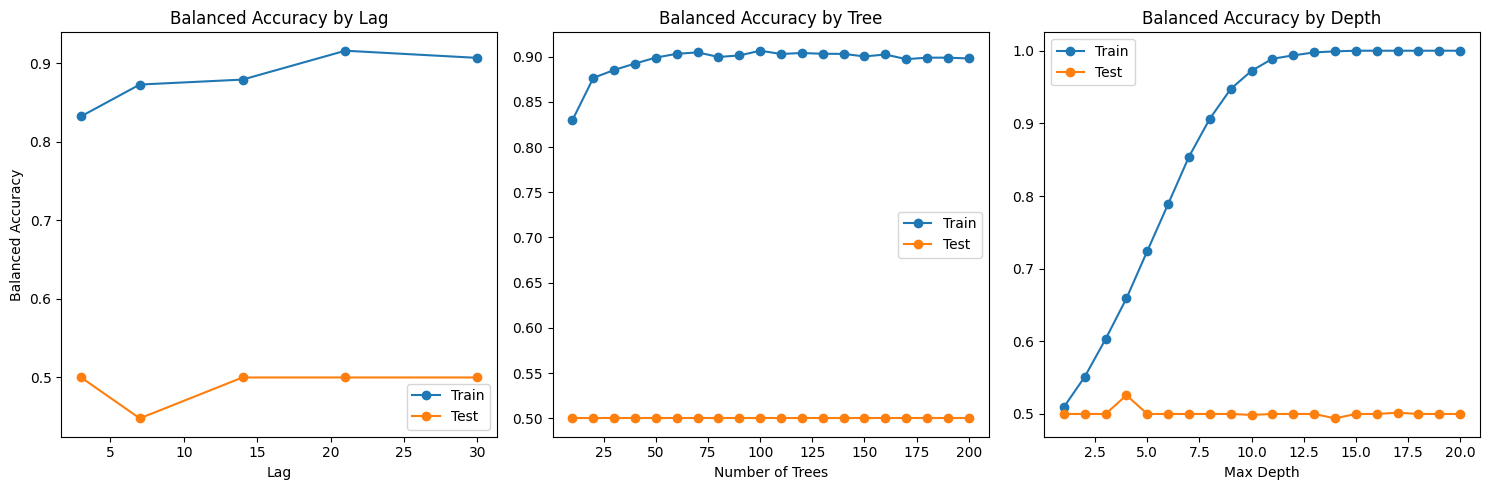

In [16]:
import matplotlib.pyplot as plt

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

# Balanced Accuracy by Lag
ax1.plot([3, 7, 14, 21, 30], train_bacc["by_lag"], label="Train", marker='o')
ax1.plot([3, 7, 14, 21, 30], test_bacc["by_lag"], label="Test", marker='o')
ax1.set_title("Balanced Accuracy by Lag")
ax1.set_xlabel("Lag")
ax1.set_ylabel("Balanced Accuracy")
ax1.legend()

# Balanced Accuracy by Tree
ax2.plot(range(10, 201, 10), train_bacc["by_tree"], label="Train", marker='o')
ax2.plot(range(10, 201, 10), test_bacc["by_tree"], label="Test", marker='o')
ax2.set_title("Balanced Accuracy by Tree")
ax2.set_xlabel("Number of Trees")
ax2.legend()

# Balanced Accuracy by Depth
ax3.plot(range(1, 21), train_bacc["by_depth"], label="Train", marker='o')
ax3.plot(range(1, 21), test_bacc["by_depth"], label="Test", marker='o')
ax3.set_title("Balanced Accuracy by Depth")
ax3.set_xlabel("Max Depth")
ax3.legend()

plt.tight_layout()
plt.show()

In [ ]:
for symbol in VN30:
    data = preprocess(symbol, lag=30, val=0.2, lag_label=True)
    X_train, Y_train = data["train"]
    X_test, Y_test = data["test"]

    model = RandomForestClassifier(
        n_estimators=100,
        max_depth=8,
        random_state=42
    )

    model.fit(X_train, Y_train)

    train_preds = model.predict(X_train)
    test_preds = model.predict(X_test)

    print(f"Symbol: {symbol}")
    print(f"Train Balanced Accuracy: {balanced_accuracy_score(Y_train, train_preds)}")
    print(f"Test Balanced Accuracy: {balanced_accuracy_score(Y_test, test_preds)}")
    print(f"Test Confusion Matrix:\n{confusion_matrix(Y_test, test_preds)}\n")